# Attrition Predictive Pipeline - Interactive Testing

This notebook allows you to interactively run the end-to-end attrition pipeline. It follows standard modular practices for Data (Chronon-style) and Models (SageMaker-ready).

## ⚙️ Initial Setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import get_snowpark_session, run_pipeline_sql, load_training_data
from feature_engineering import AttritionFeatureEngineer
from train_model import train_attrition_model

print("✅ Libraries loaded.")

✅ Libraries loaded.


## ❄️ 1. Snowflake Connectivity & Data Engineering
First, we establish a Snowpark session. This session will be used to execute the 4-stage SQL waterfall.

In [2]:
session = get_snowpark_session()
print(f"Connected to: {session.get_current_account()}")

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVv

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZNLc9owFIX%2Fikdd25LNw6DBZGhIGmYSwvBImu6ELUBFlhxdGZt%2FX5lHJ10km%2B5k%2BVx9594jDW7qXHoHbkBolaAwIMjjKtWZUNsErZb3fg95YJnKmNSKJ%2BjIAd0MB8ByWdBRaXdqzt9LDtZzBymgzY8ElUZRzUAAVSznQG1KF6OnRxoFhDIAbqzDoUtJBsKxdtYWFOOqqoKqFWizxREhBJM%2BdqpG8g19QBRfMwqjrU61vJbUrqdPECEm7QbhFI4wuxR%2BF%2Bo8gq8o67MI6MNyOfNnz4sl8kbX7m61gjLnZsHNQaR8NX88GwDnYP3OSNxrk6AEv3Kz86OgMOLALJdC7QNQutpItuepzovSOkTgVnjDMyz1VrjBTcYJKvYiix9%2Fd3bP49XruP%2BWxke5tmxdh6HMe%2Bvp689pr7u5Y%2BTH4q3e36XIe7nGHDUxTwBKPlFNuNZtkajrk45P2sswpqRHo27QCtu%2FkDd2BoVi9lR57SA%2FsqKAoOK1UOnJnfvGf41jXu8ZZ3Gvr%2BYm7z68xK1OjAE0bsJD5%2FtDTw7M8L%2BmMsAfj7rcy6mLajKeaSnSo3evTc7s50mGQXjaEZm%2FOUkpz5mQoywzHMAlKqWubg13PhJkTckRHp6p%2Fz6

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.30.0,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483307861666,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059


Connected to: "bqa07840"


In [6]:
# Execute the SQL Waterfall (C1 -> C2 -> C3 -> C4 -> C5)
# Note: This might take a few minutes depending on your warehouse size.
run_pipeline_sql(session, sql_dir="../sql")

INFO:data_loader:Executing c1_target_variable.sql...
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponderURL': 'http://ocsp.digicert.com', 'errorMessage': '254014: 254014: Failed to get OCSP response after 1 attempt.', 'insecureMode': False, 'failOpen': True, 'cacheEnabled': True, 'cacheHit': False}
ERROR:snowflake.connector.ocsp_sn

## 📊 2. Data Inspection
Load the master table into a Pandas DataFrame for exploration.

In [7]:
snowpark_df = load_training_data(session)
df = snowpark_df.limit(10000).to_pandas()
print(f"Retrieved {len(df)} sample rows.")
df.head()

INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Attrition_Master_Table...
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponderURL': 'http://ocsp.digicert.com', 'errorMessage': '254014: 254014: Failed to get OCSP response after 1 attempt.', 'insecureMode': False, 'failOpen': True, 'cacheEnabled': True, 'cacheHit': Fal

Retrieved 10000 sample rows.


,ORG_URI,COHORT_MONTH,HISTORICAL_ATTRITION_DECISION,TARGET_CURRENT_MONTH,FLIP_DATE,ATTRITION_DATE,STATUS_ACCOUNT_COUNT,STATUS_ACTIVE_COUNT,TARGET_3M,TARGET_6M,...,ENT_CASE_FEES_COUNT_LAG1,ENT_CASE_FEES_COUNT_LAG2,ENT_CASE_DISPUTES_COUNT_LAG1,ENT_CASE_DISPUTES_COUNT_LAG2,ENT_CASE_PUMP_ISSUES_COUNT_LAG1,ENT_CASE_PUMP_ISSUES_COUNT_LAG2,ENT_CASE_TOTAL_EXCL_TERM_COUNT_LAG1,ENT_CASE_TOTAL_EXCL_TERM_COUNT_LAG2,ENT_CASE_OTHER_COUNT_LAG1,ENT_CASE_OTHER_COUNT_LAG2
0,entities/35fv8Ww,2024-06-01,Healthy,0.0,None,None,2.0,2.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,entities/35fv8Ww,2024-07-01,Healthy,0.0,None,None,2.0,2.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,entities/35fv8Ww,2024-08-01,Healthy,0.0,None,None,2.0,2.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,entities/35fv8Ww,2024-09-01,Healthy,0.0,None,None,2.0,2.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,entities/35fv8Ww,2024-10-01,Healthy,0.0,None,None,2.0,2.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


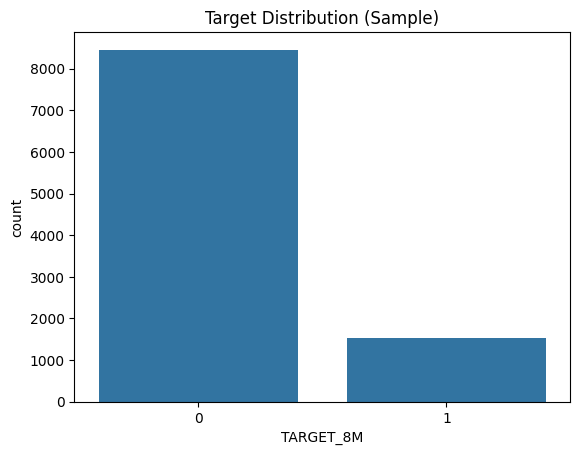

In [8]:
# Target Balance Check
sns.countplot(x='TARGET_8M', data=df)
plt.title('Target Distribution (Sample)')
plt.show()

## Section 2.5: Multi-Horizon Feature Profiling

In [9]:
from feature_profiling import MultiHorizonProfiler
import logging

# 1. Initialize the profiler
pd.set_option('display.max_rows', None)
profiler = MultiHorizonProfiler(targets=['TARGET_6M', 'TARGET_8M', 'TARGET_12M'])

# 2. Retrieve a 1% random sample from Snowflake
print("Retrieving sample from Snowflake (this may take a minute)...")
snowpark_df = load_training_data(session)
sample_df = snowpark_df.sample(0.01).to_pandas()
sample_df.columns = [c.upper() for c in sample_df.columns]

# 3. Run profiling (feature_list is now optional and auto-detected)
# This will calculate IV, PSI, and Mutual Information
results_df = profiler.run_profiling(sample_df)

# 4. Display results for 6-Month Horizon
print("\n--- Top Features by IV (Information Value) for 8-Month Horizon ---")
# Note: The column name in the results is 'Total_IV'
display(results_df[results_df['Horizon'] == 'TARGET_8M'].sort_values('Total_IV', ascending=False))

# 5. Horizon Comparison
if not results_df.empty:
    pivot_iv = results_df.pivot(index='Feature', columns='Horizon', values='Total_IV')
    print("\n--- IV Comparison across Horizons (Top 50) ---")
    display(pivot_iv.sort_values('TARGET_8M', ascending=False).head(50))


INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Attrition_Master_Table...


Retrieving sample from Snowflake (this may take a minute)...


ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'sfc-prod2-ds1-18-customer-stage.s3.us-west-2.amazonaws.com', 'certId': 'MEcwBwYFKw4DAhoEFKF1UQWdIRDSAbkIG3Mzjxw8x71fBBSBuA5jiokSGOX6OztQlZ/m5ZAThQIQCd8qwlDJcSCxEfK48eVFkQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUoXVRBZ0hENIBuQgbczOPHDzHvV8EFIG4DmOKiRIY5fo7O1CVn+blkBOFAhAJ3yrCUMlxILER8rjx5UWR', 'ocspResponderURL': 'http://ocsp.


--- Top Features by IV (Information Value) for 8-Month Horizon ---


,Feature,Horizon,Total_IV,Total_PSI,Max_Lift,Mutual_Information,Missing_Pct
135,ENT_CASE_PUMP_ISSUES_COUNT,TARGET_8M,9.983793,0,2.445797,0.001297,0.000000
132,ENT_CASE_CLAIMS_COUNT,TARGET_8M,9.983793,0,2.445797,0.002033,0.000000
133,ENT_CASE_FEES_COUNT,TARGET_8M,9.983793,0,2.445797,0.000506,0.000000
134,ENT_CASE_DISPUTES_COUNT,TARGET_8M,9.983793,0,2.445797,0.000798,0.000000
131,ENT_CASE_APPLICATION_FRAUD_COUNT,TARGET_8M,9.961029,0,2.445797,0.002181,0.000000
129,ENT_CASE_TERMINATION_NON_VAS_COUNT,TARGET_8M,9.919947,0,2.445797,0.000112,0.000000
130,ENT_CASE_AUTHORIZATION_COUNT,TARGET_8M,9.890008,0,2.445797,0.000000,0.000000
127,ENT_CASE_JUNK_EMAIL_COUNT,TARGET_8M,9.858120,0,2.445797,0.001008,0.000000
128,ENT_CASE_PAYMENT_BILLING_REC_COUNT,TARGET_8M,9.851624,0,2.445797,0.000247,0.000000
126,ENT_CASE_FEE_WAIVER_COUNT,TARGET_8M,9.816072,0,2.445797,0.001058,0.000000



--- IV Comparison across Horizons (Top 50) ---


Horizon,TARGET_12M,TARGET_6M,TARGET_8M
Feature,,,
ENT_CASE_FEES_COUNT,9.615162,9.752749,9.983793
ENT_CASE_DISPUTES_COUNT,9.615162,9.752749,9.983793
ENT_CASE_CLAIMS_COUNT,9.615162,9.752749,9.983793
ENT_CASE_PUMP_ISSUES_COUNT,9.615162,9.752749,9.983793
ENT_CASE_APPLICATION_FRAUD_COUNT,9.592403,9.720774,9.961029
ENT_CASE_TERMINATION_NON_VAS_COUNT,9.584010,9.680583,9.919947
ENT_CASE_AUTHORIZATION_COUNT,9.543461,9.636610,9.890008
ENT_CASE_JUNK_EMAIL_COUNT,9.507204,9.586150,9.858120
ENT_CASE_PAYMENT_BILLING_REC_COUNT,9.496482,9.583496,9.851624


## 🧠 3. Feature Engineering & Preprocessing
Validate that the `AttritionFeatureEngineer` correctly handles scaling and encoding.

In [11]:
fe = AttritionFeatureEngineer()
X, y = fe.preprocess_data(df)
print(f"Features defined: {len(fe.feature_cols)}")
X.head()

Features defined: 3


,ENT_GALLONS_VELOCITY_3V12,IS_TRUCKING_INDUSTRY,ACCOUNT_COUNT
0,1.0,1,1
1,1.0,1,1
2,1.0,1,1
3,1.0,1,1
4,1.0,1,1


## 🚀 4. End-to-End Training
Run the full pipeline to train the model and generate artifacts.

In [5]:
train_attrition_model("8M")
print("✅ Pipeline execution complete. Check artifacts/ folder for model and plots.")

INFO:train_model:Starting training pipeline for 8M horizon...
INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecompu

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZNfc%2BIgFMW%2FSoZ9DhDNqmWMHavT0Rl3a6Ntp33DBC0rgcglRr99iX92ug%2Fty74Rci6%2Fc%2B%2BB%2Fu2hUMFeWJBGJyjCFAVCZyaXepOgp%2BV92EMBOK5zrowWCToKQLeDPvBClWxYuXedil0lwAX%2BIA2s%2BZGgympmOEhgmhcCmMvYYvhrxlqYMg4grPM4dCnJQXrWu3MlI6Sua1y3sbEb0qKUEnpDvKqR%2FECfEOX3jNIaZzKjriUH39MXiIjQuEF4hSfML4V3Up9H8B1ldRYBmyyX83D%2BsFiiYHjtbmQ0VIWwC2H3MhNP6exsALyD1Y7Tbi%2BmuIKw9rMLW7i0cs%2BdUFJvMWhTrxXfiswUZeU8AvsVWYucKLORfnDTcYLKrcwzvl2N0jh%2BnJX1g1qnb%2FZQzdp3k8dXU%2F1ZLV7o7IXv5FRHr8MMBc%2FXmFtNzFOASkx1E67zW7TVCWkctuky6jIasbiNO5S%2BoWDsDUrN3any2kFx5GUJuBYHqbOTO%2F9N%2Fhon4rDlgnd7Nzq1RWfy3G3%2F7BIAQ5rw0Pn%2BsJMDO%2FivqfTJ56Mu9%2FK3j2o6nhsls2Nwb2zB3ddJRjg67cg8XJ%2BkTBRcqmGeWwHgE1XK1CMrvI8EO

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.30.0,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483297559638,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059
INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Attrition_Master_Table...
INFO:train_model:Data Filtering: Removed 12476802 rows. Clean set: 15688459 rows.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response a

[LightGBM] [Info] Number of positive: 1586830, number of negative: 10963937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.377044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1094
[LightGBM] [Info] Number of data points in the train set: 12550767, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.126433 -> initscore=-1.932873
[LightGBM] [Info] Start training from score -1.932873


INFO:train_model:Model Results: AUC-ROC: 0.7933, PR-AUC: 0.4127
INFO:train_model:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94   2740985
           1       0.61      0.16      0.26    396707

    accuracy                           0.88   3137692
   macro avg       0.75      0.57      0.60   3137692
weighted avg       0.86      0.88      0.85   3137692

INFO:train_model:Generating Lift Chart...
INFO:train_model:Saved model and feature engineer to attrition_pipeline/artifacts
INFO:train_model:Saved feature importance plot to attrition_pipeline/artifacts


✅ Pipeline execution complete. Check artifacts/ folder for model and plots.


## 5. Pipeline Step: Batch Inference for Latest Snapshot
In this phase, we use the trained baseline model to score the most recent cross-section of data in the master table (`COHORT_MONTH`). It applies identical preprocessing logic via the cached `FeatureEngineer` and outputs the final probabilities to the artifacts directory.


In [6]:
import os
import pandas as pd
from predict_model import predict_latest_snapshot  # 👈 ¡ESTA ES LA LÍNEA QUE FALTA!

# 1. Define paths
output_data_dir = os.environ.get('SM_OUTPUT_DATA_DIR', 'attrition_pipeline/artifacts')
preds_path = os.path.join(output_data_dir, 'predictions_latest_8M.csv')

# 2. FORCE EXECUTION (Call the inference function before reading)
print(f"🚀 Starting inference pipeline to update predictions...")
try:
    # This calls your function defined in the script to pull data and score it
    predict_latest_snapshot(horizon="8M")
    print("✅ Inference complete and file updated.")
except Exception as e:
    print(f"❌ Error during inference: {e}")

# 3. Load the results (now refreshed)
print(f"\n--- Loading Inference Results from {preds_path} ---")
if os.path.exists(preds_path):
    preds_df = pd.read_csv(preds_path)
    print(f"✅ Loaded {len(preds_df)} prediction records.")
    
    # Show the updated top 10 highest-risk entities
    display(preds_df.head(10))
else:
    print("❌ Predictions file not found even after execution attempt.")


INFO:predict_model:Starting inference pipeline for 8M horizon on latest snapshot...
INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.14.0, Python Version: 3.8.0, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.


🚀 Starting inference pipeline to update predictions...


ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider checking for OCSP URLs being blocked
 {'driver': 'PythonConnector', 'version': '3.14.0', 'eventType': 'RevocationCheckFailure', 'eventSubType': 'OCSPResponseCacheDownloadFailed|OCSPResponseFetchFailure', 'sfcPeerHost': 'bqa07840.us-west-2.privatelink.snowflakecomputing.com', 'certId': 'MEcwBwYFKw4DAhoEFKfEuLPcW7VYHqfX8TrFafVvSNeJBBR0hYDAZsffN97PvSk3qgMdvu3NFwIQDTE9kLe5RBNwiIraRbCgwQ==', 'ocspRequestBase64': 'ME8wTTBLMEkwRzAHBgUrDgMCGgQUp8S4s9xbtVgep9fxOsVp9W9I14kEFHSFgMBmx9833s+9KTeqAx2+7c0XAhANMT2Qt7lEE3CIitpFsKDB', 'ocspResponderURL': 'http://ocsp.digicert.com', 'errorMessage': '254014: 254014: Failed to get OCSP response after 1 attempt.', 'insecureMode': False, 'failOpen': True, 'cacheEnabled': True, 'cacheHit': False}
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. 

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://myapps.wexinc.com/app/snowflake/exkaea789nRrm6HV7357/sso/saml?SAMLRequest=pZNdU%2BIwFIb%2FSid73SYtYDFDcUBGxUHko7oud7ENGGmTmpPSsr9%2BUz523Au92bs0fU%2Be95w36V3VeebsuAahZIR8jyCHy0SlQm4i9BTfuF3kgGEyZZmSPEJ7Duiq3wOWZwUdlOZNLvhHycE49iAJtPkRoVJLqhgIoJLlHKhJ6HLwMKGBRygD4NpYHDqVpCAs682YgmJcVZVXtTylNzgghGByia2qkfxAnxDF94xCK6MSlZ1LatvTFwgfk3aDsApLmJ0Kh0IeR%2FAd5fUoAnoXxzN39riMkTM4d3etJJQ510uudyLhT4vJ0QBYB68fjITdNvFKcCs7OzfwCi12zPBMyK0HUlXrjG15ovKiNBbh2RVe8xRnaiPs4MajCBVbkSb61208YcvJ6n06vK%2FnctXZTFuPL%2Ffv5PdcMp9Pf8bi9mU4D6sEOc%2FnmIMm5jFAyceyCdfYLRJcuKTttkjsh9QntNX2AtJZIWdkDQrJzKHy3EG%2BZ0UBXsVrIZODO%2FuN%2FxrHvN4yzsLupVzo%2FOLuOWx1QgygcBMeOt4fenCg%2B%2F81lR7%2BfNTpXk5tVOPRTGUi2Ts3SufMfJ2k7%2FmHHZG664OU8pyJbJCmmgPYRLNMVdeaWx8RMrrkCPeP1H8fQP8P&

INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.30.0,
"python.version" : 3.8.0,
"python.connector.version" : 3.14.0,
"python.connector.session.id" : 14816483297587918,
"os.name" : Windows

INFO:data_loader:Successfully connected to Snowflake as W515059
INFO:data_loader:Loading data from WORKSPACE.digitalda_stage.ML_Attrition_Master_Table...
INFO:predict_model:Identified latest valid COHORT_MONTH for inference: 2026-03-01 00:00:00
INFO:predict_model:Downloading 255932 rows for the snapshot 2026-03-01 00:00:00 into Pandas...
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt.
ERROR:snowflake.connector.ocsp_snowflake:Failed to get OCSP response after 1 attempt. Consider che

✅ Inference complete and file updated.

--- Loading Inference Results from attrition_pipeline/artifacts\predictions_latest_8M.csv ---
✅ Loaded 255932 prediction records.


,ORG_URI,COHORT_MONTH,ACCOUNT_COUNT,STATUS_ACTIVE_COUNT,ACCOUNT_DETAILS_LIST,HAS_INELIGIBLE_ACCOUNT,CONTACT_ACCOUNT_ID,PREDICTION_SCORE_8M,PREDICTION_RANK
0,entities/4c4RM99,2026-03-01,1,1,"[{""account_id"": ""9100013996944"", ""credit_risk_...",True,9100013996944,0.821484,1
1,entities/7Eg5SUE,2026-03-01,1,1,"[{""account_id"": ""9100013943142"", ""credit_risk_...",True,9100013943142,0.818670,2
2,entities/4swGt6C,2026-03-01,1,1,"[{""account_id"": ""9100014004144"", ""credit_risk_...",True,9100014004144,0.817914,3
3,entities/5zA0N6X,2026-03-01,1,3,"[{""account_id"": ""9100013977792"", ""credit_risk_...",True,9100013977792,0.808909,4
4,entities/4bkyXAN,2026-03-01,1,1,"[{""account_id"": ""9100013983102"", ""credit_risk_...",True,9100013983102,0.801426,5
5,entities/q64L1qx,2026-03-01,1,1,"[{""account_id"": ""9100013738239"", ""credit_risk_...",True,9100013738239,0.799867,6
6,entities/K9K7UXc,2026-03-01,1,1,"[{""account_id"": ""9100013927554"", ""credit_risk_...",True,9100013927554,0.796951,7
7,entities/5PvprCR,2026-03-01,1,1,"[{""account_id"": ""9100013954572"", ""credit_risk_...",True,9100013954572,0.795797,8
8,entities/3tw5gTL,2026-03-01,1,1,"[{""account_id"": ""9100013897080"", ""credit_risk_...",True,9100013897080,0.794195,9
9,entities/3p9DsDc,2026-03-01,1,1,"[{""account_id"": ""9100013871106"", ""credit_risk_...",True,9100013871106,0.793558,10
